In [2]:
from ultralytics import YOLO
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import time

# ==========================================
# Experiment 2 Configuration
# ==========================================

DATA_YAML = "/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml"

PROJECT_DIR = Path("/workspace/runs/cardd")
EXPERIMENT_NAME = "experiment_2_reduced_augmentation"
RUN_DIR = PROJECT_DIR / EXPERIMENT_NAME

EPOCHS = 100
BATCH = 16
IMG_SIZE = 640

SEED = 42
WORKERS = 4

print("Experiment 2 - Reduced Dataset + Augmentation")
print("=" * 50)
print(f"Dataset : {DATA_YAML}")
print(f"Epochs  : {EPOCHS}")
print(f"Batch   : {BATCH}")
print(f"Image   : {IMG_SIZE}")
print(f"Seed    : {SEED}")
print(f"Run Dir : {RUN_DIR}")

Experiment 2 - Reduced Dataset + Augmentation
Dataset : /workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml
Epochs  : 100
Batch   : 16
Image   : 640
Seed    : 42
Run Dir : /workspace/runs/cardd/experiment_2_reduced_augmentation


In [3]:
from ultralytics.data.utils import check_det_dataset

data = check_det_dataset(DATA_YAML)

print("Dataset Path:")
print(data["path"])

print("\nTrain:")
print(data["train"])

print("\nValidation:")
print(data["val"])

print("\nClasses:")
print(data["names"])

print("\nNumber of Classes:")
print(data["nc"])

Dataset Path:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced

Train:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/train

Validation:
/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/images/val

Classes:
{0: 'dent', 1: 'scratch', 2: 'crack', 3: 'glass shatter', 4: 'lamp broken', 5: 'tire flat'}

Number of Classes:
6


In [4]:
from pathlib import Path

DATASET_ROOT = Path("/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced")

for split in ["train", "val", "test"]:
    image_dir = DATASET_ROOT / "images" / split
    label_dir = DATASET_ROOT / "labels" / split

    images = list(image_dir.glob("*"))
    labels = list(label_dir.glob("*.txt"))

    print(
        f"{split.upper():5} | "
        f"Images: {len(images):4} | "
        f"Labels: {len(labels):4}"
    )

TRAIN | Images: 1408 | Labels: 1408
VAL   | Images:  810 | Labels:  810
TEST  | Images:  375 | Labels:  374


In [5]:
model = YOLO("yolo11n.pt")

print("✅ YOLO11n loaded successfully")
print(f"Model: {model.model_name if hasattr(model, 'model_name') else 'YOLO11n'}")

✅ YOLO11n loaded successfully
Model: yolo11n.pt


In [6]:
start_time = time.time()

results = model.train(
    data=DATA_YAML,

    # ======================================
    # Training
    # ======================================

    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=0,
    workers=WORKERS,

    # ======================================
    # Reproducibility
    # ======================================

    seed=SEED,
    deterministic=True,

    # Same optimizer strategy as baseline
    optimizer="auto",

    # ======================================
    # Data Augmentation
    # ======================================

    degrees=5.0,
    translate=0.15,
    scale=0.60,

    fliplr=0.50,
    flipud=0.0,

    mosaic=1.0,
    mixup=0.10,
    copy_paste=0.10,

    # ======================================
    # Hardware
    # ======================================

    amp=True,

    # ======================================
    # Experiment Tracking
    # ======================================

    project=str(PROJECT_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,

    plots=True,
    save=True,
    verbose=True
)

elapsed_minutes = (time.time() - start_time) / 60

print("\n" + "=" * 60)
print("✅ EXPERIMENT 2 TRAINING COMPLETED")
print("=" * 60)
print(f"Training time: {elapsed_minutes:.2f} minutes")

New https://pypi.org/project/ultralytics/8.4.152 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.144 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA A40, 45488MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspace/CarDD_YOLO_Reduced/CarDD_YOLO_Reduced/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

In [8]:
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = RUN_DIR / "weights" / "last.pt"

print("Best weights:")
print(BEST_WEIGHTS)
print(BEST_WEIGHTS.exists())

print("\nLast weights:")
print(LAST_WEIGHTS)
print(LAST_WEIGHTS.exists())

Best weights:
/workspace/runs/cardd/experiment_2_reduced_augmentation/weights/best.pt
True

Last weights:
/workspace/runs/cardd/experiment_2_reduced_augmentation/weights/last.pt
True


In [9]:
RESULTS_CSV = RUN_DIR / "results.csv"

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

print("Results loaded successfully.")
print(f"Number of epochs recorded: {len(df)}")

display(df.tail())

Results loaded successfully.
Number of epochs recorded: 100


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,1224.62,0.90994,0.71528,1.14090,0.67130,0.65809,0.65529,0.49045,1.44792,1.53402,1.54226,0.00006,0.00006,0.00006
96,97,1237.03,0.92293,0.72561,1.15364,0.65828,0.66045,0.65365,0.48875,1.45959,1.54175,1.54551,0.00005,0.00005,0.00005
97,98,1248.10,0.92250,0.71649,1.14804,0.65206,0.67160,0.65098,0.48929,1.44437,1.53480,1.53967,0.00004,0.00004,0.00004
98,99,1259.81,0.91401,0.70652,1.14492,0.67411,0.65133,0.65215,0.49044,1.44775,1.54759,1.54228,0.00003,0.00003,0.00003
99,100,1271.57,0.90059,0.71193,1.13463,0.67598,0.64617,0.65501,0.49047,1.45643,1.54729,1.55070,0.00002,0.00002,0.00002


In [10]:
best_idx = df["metrics/mAP50-95(B)"].idxmax()
best_row = df.loc[best_idx]

print("=" * 50)
print("BEST EPOCH")
print("=" * 50)

print(f"Epoch      : {int(best_row['epoch'])}")
print(f"Precision  : {best_row['metrics/precision(B)']:.4f}")
print(f"Recall     : {best_row['metrics/recall(B)']:.4f}")
print(f"mAP50      : {best_row['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95   : {best_row['metrics/mAP50-95(B)']:.4f}")

BEST EPOCH
Epoch      : 100
Precision  : 0.6760
Recall     : 0.6462
mAP50      : 0.6550
mAP50-95   : 0.4905


In [11]:
summary = {
    "Experiment": "Experiment 2 - Reduced Dataset + Augmentation",
    "Model": "YOLO11n",
    "Dataset": "CarDD Reduced",
    "Train Images": 1408,
    "Validation Images": 810,
    "Test Images": 374,
    "Epochs": EPOCHS,
    "Image Size": IMG_SIZE,
    "Batch Size": BATCH,
    "Optimizer": "Auto",
    "AMP": True,
    "Seed": SEED,

    "Augmentation": (
        "degrees=5, translate=0.15, scale=0.60, "
        "fliplr=0.50, mosaic=1.0, mixup=0.10, copy_paste=0.10"
    ),

    "Best Epoch": int(best_row["epoch"]),
    "Precision": best_row["metrics/precision(B)"],
    "Recall": best_row["metrics/recall(B)"],
    "mAP50": best_row["metrics/mAP50(B)"],
    "mAP50-95": best_row["metrics/mAP50-95(B)"],

    "Training Time (min)": elapsed_minutes
}

summary_df = pd.DataFrame([summary])

display(summary_df)

,Experiment,Model,Dataset,Train Images,Validation Images,Test Images,Epochs,Image Size,Batch Size,Optimizer,AMP,Seed,Augmentation,Best Epoch,Precision,Recall,mAP50,mAP50-95,Training Time (min)
0,Experiment 2 - Reduced Dataset + Augmentation,YOLO11n,CarDD Reduced,1408,810,374,100,640,16,Auto,True,42,"degrees=5, translate=0.15, scale=0.60, fliplr=...",100,0.67598,0.64617,0.65501,0.49047,21.820539


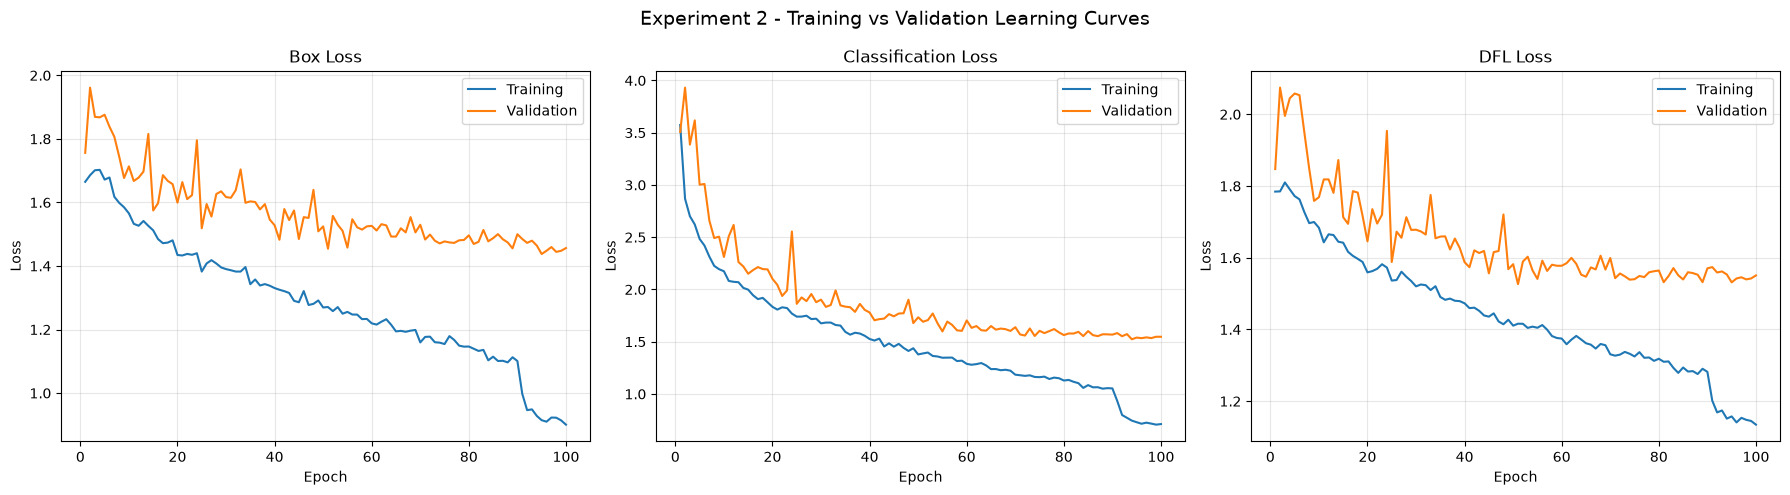

✅ Saved to:
/workspace/runs/cardd/experiment_2_reduced_augmentation/learning_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

losses = [
    ("box_loss", "Box Loss"),
    ("cls_loss", "Classification Loss"),
    ("dfl_loss", "DFL Loss")
]

for ax, (loss, title) in zip(axes, losses):

    ax.plot(
        df["epoch"],
        df[f"train/{loss}"],
        label="Training"
    )

    ax.plot(
        df["epoch"],
        df[f"val/{loss}"],
        label="Validation"
    )

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Experiment 2 - Training vs Validation Learning Curves",
    fontsize=14
)

plt.tight_layout()

LEARNING_CURVE_PATH = RUN_DIR / "learning_curves.png"

plt.savefig(
    LEARNING_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved to:")
print(LEARNING_CURVE_PATH)

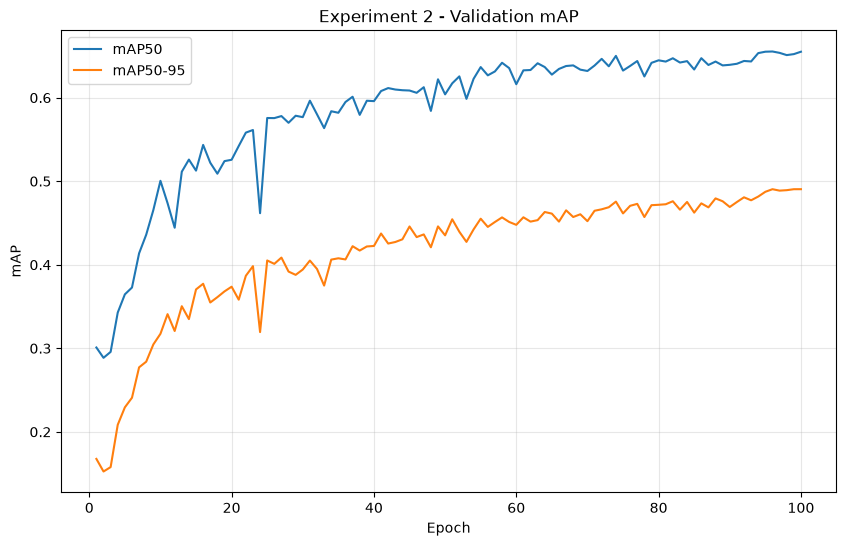

✅ Saved to:
/workspace/runs/cardd/experiment_2_reduced_augmentation/map_curves.png


In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP50"
)

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="mAP50-95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Experiment 2 - Validation mAP")
plt.legend()
plt.grid(True, alpha=0.3)

MAP_CURVE_PATH = RUN_DIR / "map_curves.png"

plt.savefig(
    MAP_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved to:")
print(MAP_CURVE_PATH)

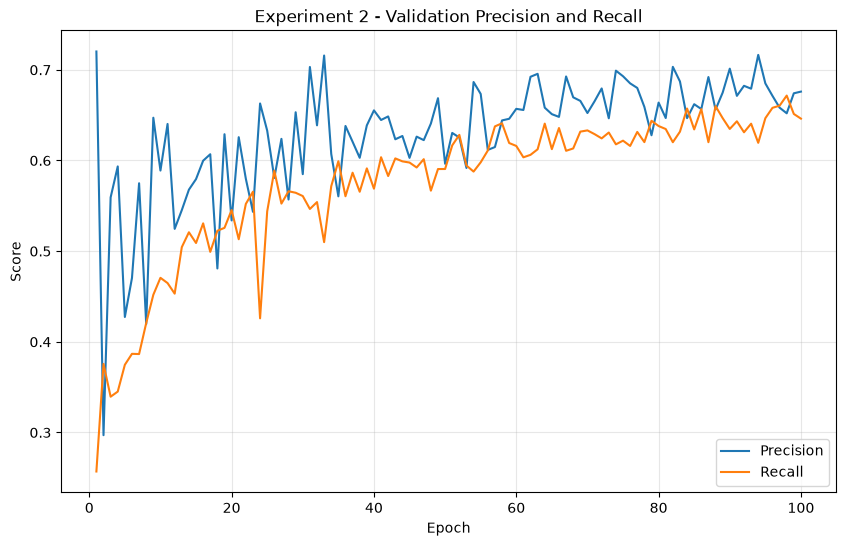

✅ Saved to:
/workspace/runs/cardd/experiment_2_reduced_augmentation/precision_recall_curves.png


In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["metrics/precision(B)"],
    label="Precision"
)

plt.plot(
    df["epoch"],
    df["metrics/recall(B)"],
    label="Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Experiment 2 - Validation Precision and Recall")
plt.legend()
plt.grid(True, alpha=0.3)

PR_CURVE_PATH = RUN_DIR / "precision_recall_curves.png"

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved to:")
print(PR_CURVE_PATH)

In [15]:
best_model = YOLO(str(BEST_WEIGHTS))

print("✅ Best model loaded successfully")
print(f"Model weights: {BEST_WEIGHTS}")

✅ Best model loaded successfully
Model weights: /workspace/runs/cardd/experiment_2_reduced_augmentation/weights/best.pt
